# Minimización del Makespan en un Taller de Trabajo con PROC OPTMODEL


## Resumen ejecutivo

Una pequeña celda de manufactura discreta debe hacer pasar cuatro piezas —un **Soporte**, una **Brida**, una **Carcasa** y un **Eje**— por una secuencia fija de tres operaciones de mecanizado cada una, compartiendo cuatro máquinas de capacidad unitaria (**Sierra**, **Fresadora**, **Taladro**, **Rectificadora**). Ninguna máquina puede ejecutar dos operaciones a la vez, y las operaciones de cada pieza deben seguir su orden tecnológico. Formulamos el programa que minimiza el makespan como un programa entero mixto en **PROC OPTMODEL** —variables de tiempo de inicio, restricciones de precedencia fin-a-inicio y restricciones disyuntivas (big-*M*) de no solapamiento entre cada par de operaciones que comparten una máquina— y lo resolvemos hasta la optimalidad demostrada.

El solucionador MILP devuelve un **makespan óptimo de 120 minutos** (`Solution Status = Optimal`, `Objective Value = 120`). El programa resultante compacta las doce operaciones de modo que cada máquina procesa como máximo una pieza a la vez y cada pieza se mecaniza Sierra/Fresadora/Taladro antes de Rectificadora en su orden requerido. Dos operaciones terminan exactamente en el minuto 120 —el esmerilado de Soporte y el fresado de Carcasa— por lo que tanto la máquina Rectificadora como la Fresadora están en la ruta crítica que fija la longitud del programa.

## Fuentes de datos

Todos los datos se definen dentro del cuaderno —sin archivos externos ni red.

| Conjunto de datos | Filas | Variables clave | Descripción |
|---------|------|---------------|-------------|
| `jobshop` | 12 | `op`, `job`, `opnum`, `machine`, `dur`, `jobname`, `mname` | Una fila por operación (4 piezas × 3 operaciones). `machine` (1–4) es la máquina que la operación necesita; `dur` es su tiempo de procesamiento en minutos; `jobname`/`mname` son etiquetas legibles de pieza y máquina. |
| `sched` | 12 | `op`, `start`, `finish` | Salida de OPTMODEL: el minuto óptimo de inicio y fin de cada operación. |
| `schedule` | 12 | `jobname`, `opnum`, `mname`, `dur`, `start`, `finish` | `jobshop` combinado con los tiempos resueltos, ordenado por máquina y luego por inicio —el programa legible por humanos. |
| `mk` | 1 | `makespan` | El makespan realizado (último tiempo de finalización). |

## El problema de programación

En un **taller de trabajo** (*job shop*), varias piezas ("trabajos") pasan cada una por una secuencia fija de operaciones, y cada operación se ejecuta en una máquina específica. Dos operaciones no pueden ocupar la misma máquina al mismo tiempo (las máquinas son recursos *unarios*), y dentro de una pieza las operaciones deben respetar su orden tecnológico. El planificador quiere tiempos de inicio para cada operación que respeten ambas reglas mientras mantiene la longitud total del programa —el **makespan**— lo más pequeña posible.

Este es un problema clásico de programación disyuntiva. Lo modelamos como un programa entero mixto:

- un **tiempo de inicio** `s[o]` continuo-pero-entero para cada operación, y una variable de makespan `Cmax`;
- **precedencia**: la operación *k+1* de una pieza comienza no antes de que termine la operación *k*;
- **capacidad disyuntiva de máquina**: para cada par de operaciones que comparten una máquina, una binaria `y` decide cuál va primero, y un término big-*M* desactiva el ordenamiento inactivo —de modo que las dos operaciones nunca puedan solaparse;
- **objetivo**: minimizar `Cmax`, que se fuerza a ser al menos el tiempo de finalización de cada operación.

PROC OPTMODEL es el procedimiento de modelado algebraico de SAS/OR; su solucionador MILP encuentra el programa más corto *demostrablemente óptimo*.

> **Una nota sobre PROC CLP.** SAS también ofrece PROC CLP, un motor de > programación con lógica de restricciones con sintaxis de programación > dedicada (actividades, recursos, precedencia). La formulación MILP de > OPTMODEL aquí resuelve el problema idéntico y devuelve un certificado de > optimalidad, cosa que la búsqueda de factibilidad de CLP no hace.

## Paso 1 — Definir la instancia del taller

Cuatro piezas, tres operaciones cada una, en cuatro máquinas. Cada fila fija la máquina que una operación necesita y su tiempo de procesamiento en minutos. Las operaciones de una pieza se listan en orden tecnológico (`opnum` 1, 2, 3).

In [1]:
DATOS jobshop;
    LONGITUD jobname $10 mname $16;
    ENTRADA op job opnum machine dur jobname $ mname $;
    DATALINES;
1  1 1 1 25 Soporte  Sierra
2  1 2 3 40 Soporte  Taladro
3  1 3 4 20 Soporte  Rectificadora
4  2 1 2 35 Brida    Fresadora
5  2 2 3 25 Brida    Taladro
6  2 3 1 15 Brida    Sierra
7  3 1 3 30 Carcasa  Taladro
8  3 2 1 20 Carcasa  Sierra
9  3 3 2 45 Carcasa  Fresadora
10 4 1 1 20 Eje      Sierra
11 4 2 2 30 Eje      Fresadora
12 4 3 4 25 Eje      Rectificadora
;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=jobshop noobs ETIQUETA;
    TÍTULO 'Instancia del taller: 4 piezas, 3 operaciones cada una, 4 máquinas';
    VAR op jobname opnum mname dur;
    ETIQUETA op="Operación" jobname="Pieza" opnum="Orden op."
             mname="Máquina" dur="Duración (min)";
EJECUTAR;

                           Instancia del taller: 4 piezas, 3 operaciones cada una, 4 máquinas                           

 Operación    Pieza  Orden op.        Máquina   Duración (min)
         1  Soporte          1  Sierra                      25
         2  Soporte          2  Taladro                     40
         3  Soporte          3  Rectificadora               20
         4  Brida            1  Fresadora                   35
         5  Brida            2  Taladro                     25
         6  Brida            3  Sierra                      15
         7  Carcasa          1  Taladro                     30
         8  Carcasa          2  Sierra                      20
         9  Carcasa          3  Fresadora                   45
        10  Eje              1  Sierra                      20
        11  Eje              2  Fresadora                   30
        12  Eje              3  Rectificadora               25




NOTE: DATA jobshop

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote jobshop (12 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=jobshop

NOTE: PROC PRINT completed: 12 observations printed, 5 variables


## Paso 2 — Resolver el programa que minimiza el makespan con PROC OPTMODEL

OPTMODEL lee la instancia, construye las variables de tiempo de inicio y de ordenamiento, plantea las restricciones de precedencia y disyuntivas, y minimiza el makespan con su solucionador MILP. El horizonte big-*M* `H` es el contenido total de trabajo —una cota superior segura sobre cualquier tiempo de inicio. El solucionador reporta el objetivo **óptimo**; escribimos los tiempos de inicio y fin elegidos en `sched`.

In [2]:
PROCEDIMIENTO optmodel;
    ESTABLECER OPS;
    num job{OPS};
    num opnum{OPS};
    num machine{OPS};
    num dur{OPS};
    READ DATOS jobshop INTO OPS=[op] job opnum machine dur;

    /* a safe big-M horizon = total work content */
    num H = sum{o IN OPS} dur[o];

    VAR s{OPS} >= 0 integer;     /* operation start time (minutes) */
    VAR Cmax >= 0;               /* makespan */

    /* technological order: op k+1 starts after op k finishes */
    con prec{a IN OPS, b IN OPS:
             job[a] = job[b] AND opnum[b] = opnum[a] + 1}:
        s[b] >= s[a] + dur[a];

    /* makespan dominates every operation's finish time */
    con span{o IN OPS}: Cmax >= s[o] + dur[o];

    /* disjunctive machine capacity: for each operation pair sharing a
       machine, binary y fixes the order; big-M relaxes the other */
    VAR y{a IN OPS, b IN OPS:
          a < b AND machine[a] = machine[b]} binary;
    con seqAB{a IN OPS, b IN OPS:
              a < b AND machine[a] = machine[b]}:
        s[b] >= s[a] + dur[a] - H * (1 - y[a,b]);
    con seqBA{a IN OPS, b IN OPS:
              a < b AND machine[a] = machine[b]}:
        s[a] >= s[b] + dur[b] - H * y[a,b];

    impvar FINISH{o IN OPS} = s[o] + dur[o];

    MIN makespan = Cmax;
    solve WITH milp;

    CREAR DATOS sched DESDE
        [op]={o IN OPS}
        START=s[o] FINISH=FINISH[o];
QUIT;

                           Instancia del taller: 4 piezas, 3 operaciones cada una, 4 máquinas                           


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            MAKESPAN
  Objective Type                Linear

  Number of Variables           157
  Bounded Above                 0
  Bounded Below                 13
  Bounded Below and Above       144
  Free                          0
  Fixed                         0

  Number of Constraints         46
  Integer Variables             156

                          Solution Summary
  Solver                        MILP
  Objective Function            MAKESPAN
  Solution Status               Optimal
  Objective Value               120.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Paso 3 — Ensamblar el programa legible

Combinar los tiempos resueltos de vuelta con las etiquetas de pieza y máquina, ordenar por máquina y luego por tiempo de inicio, e imprimir el programa. El makespan es el mayor tiempo de finalización de todas las operaciones.

In [3]:
PROCEDIMIENTO ORDENAR DATOS=jobshop out=jobs2; POR op; EJECUTAR;
PROCEDIMIENTO ORDENAR DATOS=sched   out=sol;   POR op; EJECUTAR;

DATOS schedule;
    COMBINAR jobs2 sol;
    POR op;
EJECUTAR;

PROCEDIMIENTO ORDENAR DATOS=schedule; POR mname START; EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=schedule noobs ETIQUETA;
    TÍTULO 'Programa óptimo: inicio / fin (minutos) de cada operación';
    VAR jobname opnum mname dur START FINISH;
    ETIQUETA jobname="Pieza" opnum="Orden op." mname="Máquina"
             dur="Duración (min)" START="Inicio (min)" FINISH="Fin (min)";
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=schedule MAX NOPRINT;
    VAR FINISH;
    SALIDA out=mk(ELIMINAR=_type_ _freq_) MAX=makespan;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=mk noobs ETIQUETA;
    TÍTULO 'Makespan mínimo (fin de la última operación, minutos)';
    ETIQUETA makespan="Makespan (min)";
EJECUTAR;

                               Programa óptimo: inicio / fin (minutos) de cada operación                                

  Pieza  Orden op.        Máquina   Duración (min)  Inicio (min)  Fin (min)
Brida            1  Fresadora                   35             0         35
Eje              2  Fresadora                   30            35         65
Carcasa          3  Fresadora                   45            75        120
Eje              3  Rectificadora               25            65         90
Soporte          3  Rectificadora               20           100        120
Eje              1  Sierra                      20             0         20
Soporte          1  Sierra                      25            20         45
Carcasa          2  Sierra                      20            45         65
Brida            3  Sierra                      15            65         80
Carcasa          1  Taladro                     30             0         30
Brida            2  Taladro               


NOTE: PROC SORT data=jobshop

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from jobshop.
NOTE: Wrote jobs2 (12 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from sched.
NOTE: Wrote sol (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA schedule

NOTE: Stream 1 processed 12 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 12 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=schedule

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from schedule.
NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=schedule

NOTE: PROC PRINT completed: 12 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: Output dataset 

## Paso 4 — Visualizar el programa

Damos a cada operación una **ranura** ordinal (ordenada por máquina, luego por inicio) y dibujamos su ventana temporal como una barra flotante: la barra abarca desde el minuto de inicio de la operación hasta su minuto de fin. Las ranuras 1–3 son la Fresadora, 4–5 la Rectificadora, 6–9 la Sierra y 10–12 el Taladro. La tabla directamente debajo nombra la pieza en cada ranura, de modo que el gráfico y la tabla se leen juntos. Las barras en la misma máquina nunca se solapan en el tiempo —la restricción disyuntiva hecha visible.

                       Programa por ranura (el orden de ranuras coincide con el gráfico de abajo)                       

Ranura        Máquina    Pieza  Inicio (min)  Fin (min)
     1  Fresadora      Brida               0         35
     2  Fresadora      Eje                35         65
     3  Fresadora      Carcasa            75        120
     4  Rectificadora  Eje                65         90
     5  Rectificadora  Soporte           100        120
     6  Sierra         Eje                 0         20
     7  Sierra         Soporte            20         45
     8  Sierra         Carcasa            45         65
     9  Sierra         Brida              65         80
    10  Taladro        Carcasa             0         30
    11  Taladro        Brida              35         60
    12  Taladro        Soporte            60        100

                       Programa por ranura (el orden de ranuras coincide con el gráfico de abajo)                       




NOTE: DATA ganttdata


NOTE: Read 12 rows from schedule.
NOTE: Wrote ganttdata (12 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ganttdata

NOTE: PROC PRINT completed: 12 observations printed, 5 variables
NOTE: PROC SGPLOT data=ganttdata

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


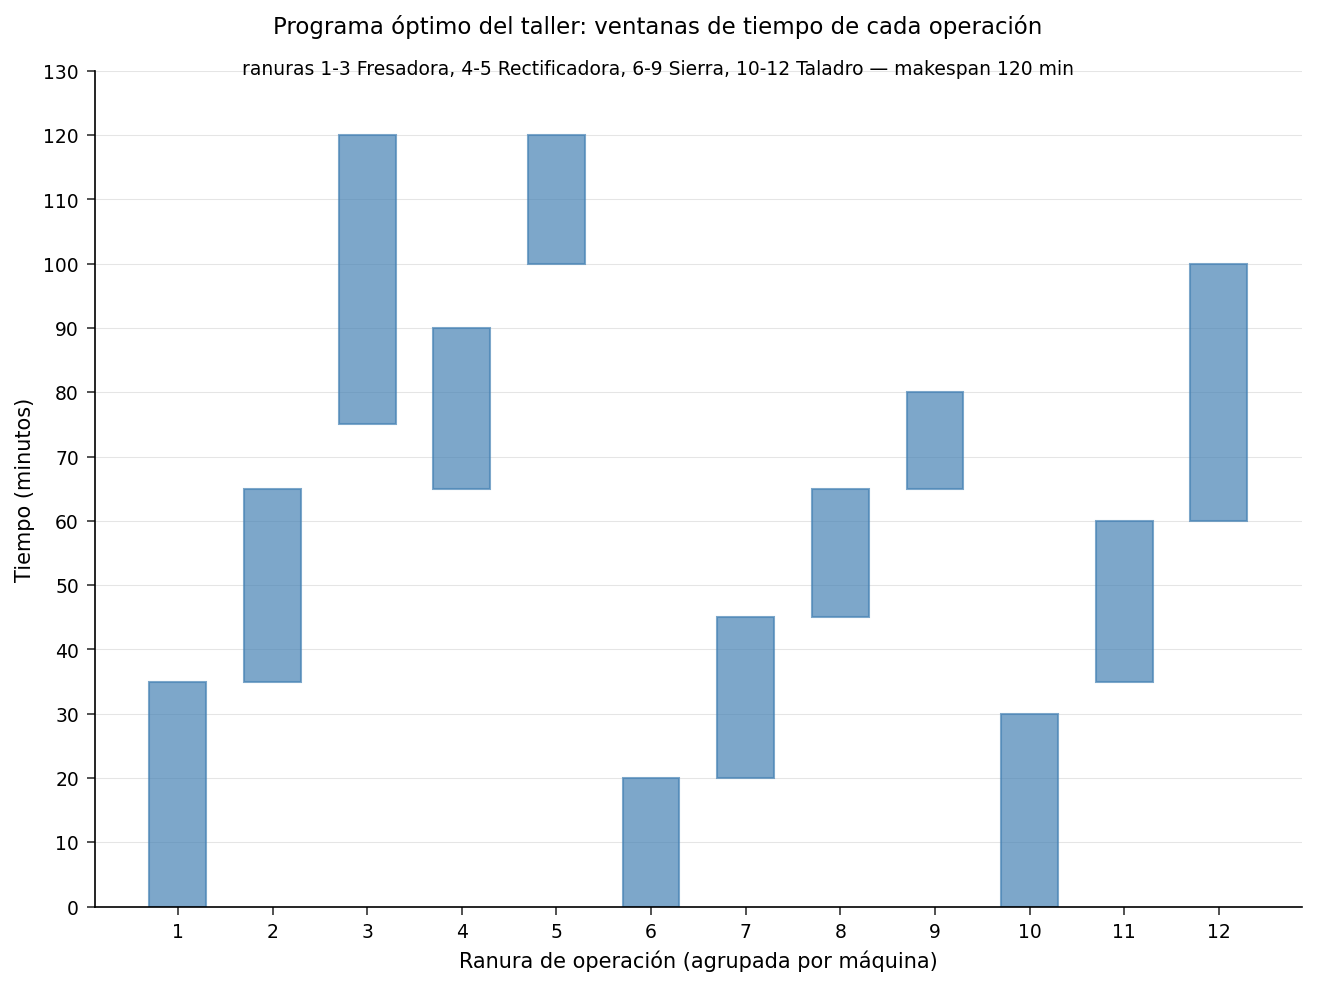

In [4]:
DATOS ganttdata;
    ESTABLECER schedule;
    slot + 1;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=ganttdata noobs ETIQUETA;
    TÍTULO 'Programa por ranura (el orden de ranuras coincide con el gráfico de abajo)';
    VAR slot mname jobname START FINISH;
    ETIQUETA slot="Ranura" mname="Máquina" jobname="Pieza"
             START="Inicio (min)" FINISH="Fin (min)";
EJECUTAR;

PROCEDIMIENTO SGPLOT DATOS=ganttdata noautolegend;
    TÍTULO 'Programa óptimo del taller: ventanas de tiempo de cada operación';
    title2 'ranuras 1-3 Fresadora, 4-5 Rectificadora, 6-9 Sierra, 10-12 Taladro — makespan 120 min';
    highlow x=slot HIGH=FINISH LOW=START / type=bar barwidth=0.65
            fillattrs=(color=steel) LINEATTRS=(color=navy);
    XAXIS ETIQUETA='Ranura de operación (agrupada por máquina)' integer
          VALUES=(1 HASTA 12 POR 1);
    YAXIS ETIQUETA='Tiempo (minutos)' grid VALUES=(0 HASTA 130 POR 10);
EJECUTAR;
TÍTULO;

## Interpretación de los resultados

- **Optimalidad.** El solucionador MILP devolvió `Solution Status = Optimal` con `Objective Value = 120`, por lo que **120 minutos es el makespan más corto demostrablemente posible** para esta instancia —ningún programa puede terminar antes. Este certificado es lo que la formulación de programación matemática le aporta por encima de una búsqueda de factibilidad pura.

- **El programa respeta cada restricción.** Leyendo la tabla por máquina, no hay dos operaciones en la misma máquina que se solapen (p. ej. en la Sierra: Eje 0–20, Soporte 20–45, Carcasa 45–65, Brida 65–80), y cada pieza corre en orden tecnológico (p. ej. Carcasa: Taladro 0–30, luego Sierra 45–65, luego Fresadora 75–120). El gráfico de barras flotantes muestra lo mismo: dentro de la banda de ranuras de cada máquina las ventanas temporales se disponen sin colisión.

- **Qué fija la longitud del programa.** Dos operaciones terminan exactamente en el minuto 120 —la Rectificadora del Soporte (ranura 5) y la Fresadora de la Carcasa (ranura 3). Ambas tocan el makespan, por lo que las máquinas Rectificadora y Fresadora están en la ruta crítica; recortar más el makespan requeriría cambiar la instancia misma (operaciones más rápidas, una máquina adicional o precedencia relajada), no meramente resecuenciar.

- **Cómo escala.** La formulación crece de forma natural: añada una máquina como otro valor de `machine`, añada piezas como más filas de `jobshop`, o modele fechas de liberación y de vencimiento acotando `s[o]` y añadiendo restricciones de fecha de vencimiento. Permitir que una máquina ejecute varios trabajos a la vez (capacidad >1) reemplaza la disyunción por pares con una restricción de recurso acumulativo. El mismo MILP de OPTMODEL maneja entonces reglas de taller más ricas sin cambiar el solucionador.